# Section 1.3 — Processing Times

This notebook fits and evaluates the elapsed **start → complete** duration used by the simulator. It is deliberately aligned with the resource-aware runtime: an activity is requested, allocated to an on-shift and permitted resource, and only then started and assigned a duration.

The notebook prepares analysis and experiment code only. It does not train a model or run a simulation when opened.

## Scope and interface with the resource perspective

The historical target is an elapsed lifecycle duration, not a pure hands-on processing time. The resource-availability analysis shows that most elapsed `start → complete` time is waiting in the workflow lifecycle (for example, suspended work awaiting a customer response). The model should therefore be reported as an **elapsed-duration model**. Splitting active service from post-start waiting remains future work.

Resource contention is different and is not folded into this target. The runtime records it before work starts: `ACTIVITY_REQUEST → ACTIVITY_START`. `ResourceComponent` filters candidates by permission, live capacity, and the fitted availability calendar; its FIFO deferral makes resource waiting `start − request`. Once an activity has started, it is allowed to finish even if the resource's shift closes.

This separation avoids double-counting queueing time: the duration model covers the historical start-to-complete span, while the resource model adds only the simulated pre-start wait. Registering the resource component before the process component also ensures that the allocated resource is present when the contextual duration features are built.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The notebook may be opened from notebooks/ or from the repository root.
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import train_processing_time_model as T
from analysis.availability import YearlyAvailability
from simulation.components import process as P
from simulation.components import permissions as permission_models
from simulation.components.case_attributes import CaseAttributeSampler
from simulation.main import (
    AVAILABILITY_MODEL_PATH,
    CASE_ATTRIBUTES_PATH,
    DEFAULT_BPMN_PATH,
    DEFAULT_MODEL_PATH,
    ORGMODEL_PATH,
    RANDOM_SEED,
    START_DATETIME,
)

LOG_CANDIDATES = [
    ROOT / 'BPIChallenge2017.xes', ROOT / 'BPIChallenge2017.xes.gz',
    ROOT / 'data/BPIChallenge2017.xes', ROOT / 'data/BPIChallenge2017.xes.gz',
]
LOG = next((path for path in LOG_CANDIDATES if path.is_file()), None)
METRICS_PATH = ROOT / 'output/models/processing_time_metrics.json'
METRICS = json.loads(METRICS_PATH.read_text()) if METRICS_PATH.is_file() else None
ARTIFACT = Path(DEFAULT_MODEL_PATH)

# Deliberately lazy: opening the notebook never loads a large artifact.
def load_artifact():
    if not ARTIFACT.is_file():
        raise FileNotFoundError(
            f'Missing {ARTIFACT.relative_to(ROOT)}; run python setup_models.py first.'
        )
    return joblib.load(ARTIFACT)

def load_resource_models(seed=RANDOM_SEED):
    """Prepare the same fitted collaborators that simulation.main injects."""
    calendar = YearlyAvailability.from_json(AVAILABILITY_MODEL_PATH)
    permissions = permission_models.OrgModelPermissions.from_json(ORGMODEL_PATH)
    permissions.self_check()
    case_attributes = CaseAttributeSampler.from_json(CASE_ATTRIBUTES_PATH, seed=seed)
    return calendar, permissions, case_attributes


## Basic 1 — one distribution per activity

The dependency-light baseline samples a fitted parametric distribution for each activity. The runtime keeps the fitted parameters in `PROCESSING_TIME_PARAMS`, selecting log-normal, gamma, or Weibull where supported and using an exponential fallback for sparse activities. This mode needs no trained joblib artifact.

In [2]:
params = P.PROCESSING_TIME_PARAMS
families = pd.Series([family for family, _ in params.values()]).value_counts()
summary = pd.DataFrame({
    'activities': [len(params), len(P.FALLBACK_MEAN_DURATIONS)],
}, index=['fitted parametric distribution', 'exponential fallback'])
display(summary)
display(families.rename_axis('family').to_frame('activities'))


,activities
fitted parametric distribution,6
exponential fallback,20


,activities
family,
lognorm,3
gamma,2
weibull_min,1


[load] Reading XES with pm4py: /Users/danielsich/dev/Ent/bpic17-process-mining-group-assignment/BPIChallenge2017.xes …


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

[load] 1,202,267 events, 31,509 cases, 26 activities.
[instances] 41,862 paired instances → 41,862 after duration filter (0 < d ≤ 365d).
41,862 paired instances | median 0.52 h | p95 151.6 h | max 3814 h


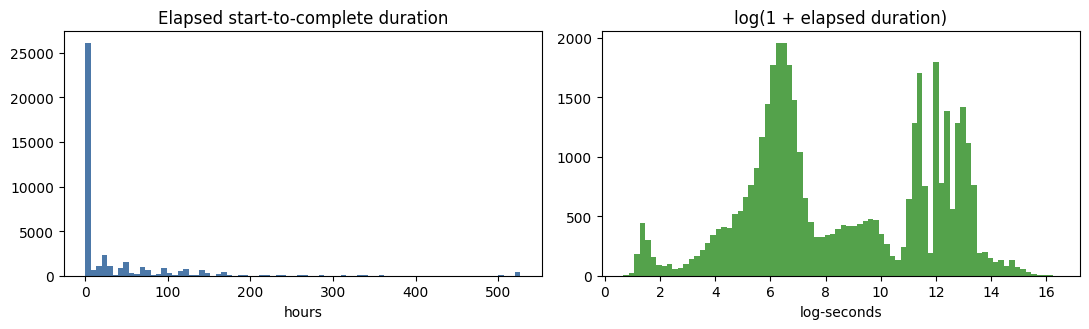

In [3]:
# Optional, log-dependent diagnostic. It only reads the source log; it does not fit or run.
if LOG is None:
    print('Raw log not found — add it to the repository root or data/ to draw this diagnostic.')
else:
    instances = T.build_instances(T.load_log(LOG))
    duration_h = instances['duration_s'] / 3600
    print(
        f'{len(instances):,} paired instances | median {duration_h.median():.2f} h | '
        f'p95 {duration_h.quantile(.95):.1f} h | max {duration_h.max():.0f} h'
    )
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
    axes[0].hist(duration_h.clip(upper=duration_h.quantile(.99)), bins=80, color='#4C78A8')
    axes[0].set(title='Elapsed start-to-complete duration', xlabel='hours')
    axes[1].hist(np.log1p(instances['duration_s']), bins=80, color='#54A24B')
    axes[1].set(title='log(1 + elapsed duration)', xlabel='log-seconds')
    plt.tight_layout()


**Decision 1 — fit `log(1 + duration)`.** The elapsed durations have a heavy right tail, so context-aware models predict their log transform and invert with `expm1`. Report both log-scale and raw-scale metrics: the first describes fit across orders of magnitude; the latter keeps large tail errors visible.

The lifecycle interpretation is important here. A small active-work interval can be separated by long `suspend → resume` waits, so a good fit to this target does not establish that the model has learned hands-on effort.

## Basic 2 — contextual point estimate

`GradientBoostingRegressor` predicts log elapsed duration from the training contract in `train_processing_time_model.FEATURE_NAMES`: activity, allocated resource, previous activity, weekday, hour, case position, case age, and prior-activity count. The model is trained on the oldest 80% of activity instances and evaluated on the newest 20%, avoiding a random split that leaks temporal process drift.

,split,train instances,test instances,log R²,raw R²,MAE (hours),RMSE (hours)
0,temporal_80_20,33489,8373,0.119235,-0.052609,30.811206,103.228782


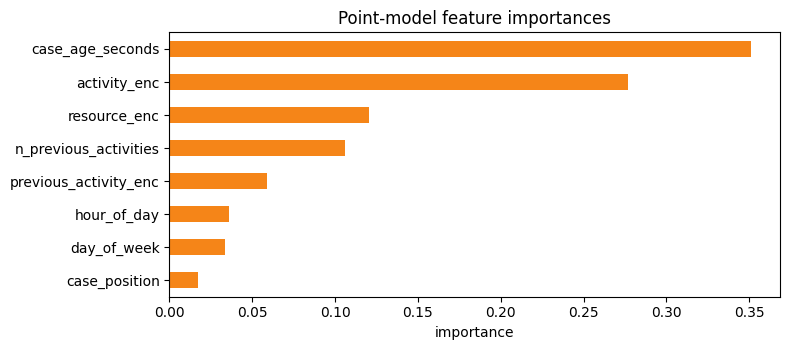

In [4]:
if METRICS is None:
    print('Metrics are absent — run python setup_models.py after adding the raw log.')
else:
    point = METRICS['point_model']
    display(pd.DataFrame([{
        'split': point['split'],
        'train instances': point['n_train'],
        'test instances': point['n_test'],
        'log R²': point['r2_log'],
        'raw R²': point['r2_raw'],
        'MAE (hours)': point['mae_seconds'] / 3600,
        'RMSE (hours)': point['rmse_seconds'] / 3600,
    }]))

    importance = pd.Series(METRICS['feature_importances']).sort_values()
    ax = importance.plot.barh(figsize=(8, 3.6), color='#F58518')
    ax.set(title='Point-model feature importances', xlabel='importance')
    plt.tight_layout()


The resource feature is now meaningful at runtime. `ResourceComponent` is registered before `ProcessComponent`, so the `ACTIVITY_START` event already carries the selected resource when the feature vector is created. The selection itself honours the Section 1.6 calendar and Section 1.7 permission context; neither the duration model nor its notebook needs to reimplement those rules.

## Advanced I — conditional quantile distribution

The advanced model fits 19 independent gradient-boosting quantile regressors (`q = 0.05, 0.10, …, 0.95`) over the same feature vector. At runtime it repairs any quantile crossings with a cumulative maximum in log space, then draws from the interpolated inverse CDF. This preserves conditional spread that the point estimator discards.

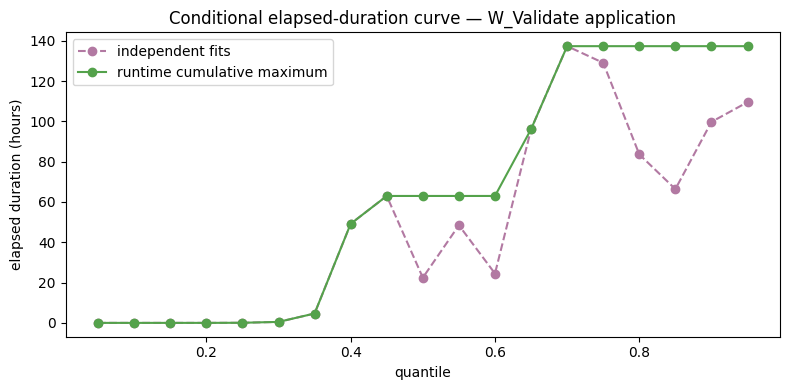

In [5]:
def feature_vector(artifact, activity, resource, previous_activity, *,
                   day=1, hour=11, position=5, case_age_s=3 * 24 * 3600):
    encoders, sentinels = artifact['encoders'], artifact['sentinels']

    def encode(name, value, fallback):
        value = value if value in set(encoders[name].classes_) else fallback
        return int(encoders[name].transform([value])[0])

    values = {
        'activity_enc': encode('activity', activity, sentinels['unknown']),
        'resource_enc': encode('resource', resource, sentinels['unknown']),
        'previous_activity_enc': encode('previous_activity', previous_activity, sentinels['no_prev']),
        'day_of_week': day, 'hour_of_day': hour, 'case_position': position,
        'case_age_seconds': case_age_s, 'n_previous_activities': position,
    }
    return np.asarray([[values[name] for name in artifact['feature_names']]], dtype=float)

# This diagnostic requires the optional trained artifact; it never retrains it.
if ARTIFACT.is_file():
    artifact = load_artifact()
    if artifact.get('quantile_models') is None:
        print('Artifact has only the point model — regenerate with python setup_models.py.')
    else:
        activities = [a for a in artifact['encoders']['activity'].classes_ if not a.startswith('__')]
        activity = 'W_Validate application' if 'W_Validate application' in activities else activities[0]
        x = feature_vector(artifact, activity, artifact['sentinels']['unknown'], artifact['sentinels']['no_prev'])
        quantiles = [float(q) for q in artifact['quantiles']]
        raw_log = np.asarray([artifact['quantile_models'][q].predict(x)[0] for q in artifact['quantiles']])
        monotone_log = np.maximum.accumulate(raw_log)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(quantiles, np.expm1(raw_log) / 3600, 'o--', color='#B279A2', label='independent fits')
        ax.plot(quantiles, np.expm1(monotone_log) / 3600, 'o-', color='#54A24B', label='runtime cumulative maximum')
        ax.set(xlabel='quantile', ylabel='elapsed duration (hours)', title=f'Conditional elapsed-duration curve — {activity}')
        ax.legend()
        plt.tight_layout()
else:
    print('Trained artifact not found — diagnostic prepared but not executed.')


In [6]:
if METRICS is not None and METRICS.get('quantile_eval') is not None:
    quantile_eval = METRICS['quantile_eval']
    display(pd.DataFrame([{
        'mean pinball loss (log)': quantile_eval['mean_pinball_loss_log'],
        '90% interval coverage': quantile_eval['coverage_90pct_interval'],
        '50% interval coverage': quantile_eval['coverage_50pct_interval'],
        'median-quantile log R²': quantile_eval['r2_log_median_quantile'],
    }]))
else:
    print('Quantile metrics are absent — regenerate the probabilistic artifact first.')


,mean pinball loss (log),90% interval coverage,50% interval coverage,median-quantile log R²
0,0.853164,0.814523,0.424101,-0.066428


**Decision 2 — evaluate a distribution as a distribution.** Mean pinball loss is the proper score for quantile predictions, while central-interval coverage shows whether the emitted distribution is calibrated. The model is an expressive stochastic approximation of elapsed lifecycle time, not a claim to recover individual active-work durations.

## Resource-aware simulation plan — prepared, not run

Every duration-mode comparison must hold the resource perspective fixed: the fitted yearly calendar (`calendar`), the causally available OrdinoR permission model (`orgmodel`), the default random allocation policy, three slots per resource, and the advanced Petri-net process with visit-conditioned branching. Changing any of these would mix processing-time effects with availability, permissions, or allocation effects.

The following cells only construct the commands and reusable post-run analysis. They do **not** call the simulator.

In [7]:
MODES = ('distribution', 'ml_model', 'ml_probabilistic')
COMMON_ARGS = (
    '--process-model', 'advanced', '--branching-mode', 'visit',
    '--availability', 'calendar', '--permissions', 'orgmodel',
)

def simulation_command(mode):
    if mode not in MODES:
        raise ValueError(f'Unknown processing-time mode: {mode}')
    return [sys.executable, '-m', 'simulation.main', '--mode', mode, *COMMON_ARGS]

prepared_commands = pd.DataFrame({
    'mode': MODES,
    'command': [' '.join(simulation_command(mode)) for mode in MODES],
})
display(prepared_commands)

# Intentionally no subprocess.run(...): after a run, copy output/event_log.csv
# and output/completed_cases.txt to a mode-specific location before the next mode.


,mode,command
0,distribution,/Users/danielsich/.local/share/virtualenvs/BPI...
1,ml_model,/Users/danielsich/.local/share/virtualenvs/BPI...
2,ml_probabilistic,/Users/danielsich/.local/share/virtualenvs/BPI...


In [8]:
def completed_instance_summary(event_log, completed_cases):
    """Summarise only naturally completed cases from one saved simulation log.

    The engine's fixed horizon censors unfinished cases. Filtering with the
    completed-case list makes that censoring explicit; it does not make the
    three modes directly comparable unless they share the same horizon and
    resource configuration. Resource wait is intentionally not inferred from
    this log because requests are internal events; record ResourceComponent
    stats()['mean_wait_seconds'] from the corresponding run instead.
    """
    log = T.load_log(Path(event_log))
    completed = set(Path(completed_cases).read_text().splitlines())
    instances = T.build_instances(log)
    instances = instances[instances['case_id'].isin(completed)].copy()
    if instances.empty:
        return pd.Series(dtype=float, name='elapsed_duration_hours')
    hours = instances['duration_s'] / 3600
    return pd.Series({
        'instances': len(hours),
        'median_hours': hours.median(),
        'mean_hours': hours.mean(),
        'std_hours': hours.std(),
        'p95_hours': hours.quantile(.95),
    }, name='elapsed_duration_hours')

# Example after a run, deliberately left disabled:
# completed_instance_summary(ROOT / 'output/event_log.csv', ROOT / 'output/completed_cases.txt')


## Reproducibility and reporting

- Rebuild the optional point and quantile artifact with `python setup_models.py`; it reuses `train_processing_time_model.py` and writes the report metrics JSON.
- For each prepared simulation command, save the event log and `completed_cases.txt` under a mode-specific output location before running the next mode; `simulation.main` otherwise overwrites the canonical event log.
- Record resource statistics alongside duration summaries: mean request-to-start wait, queued work at the horizon, and unpermitted activities. These quantify the Section 1.6–1.8 mechanism rather than being attributed to the duration model.
- Keep the seed fixed for a reproduction. For policy comparisons, use the experiment runner's common-random-number path rather than comparing unrelated one-off runs.